In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Aqui pongan la ruta dentro de su computadora a el archivo .hdf5
PATH='/Users/leopoldomorante/Desktop/vision_galaxiesML/DESI_HSC_64x64_v2.hdf5'

f = h5py.File(PATH, "r")

wave = f["spectrum/wave"]
flux = f["spectrum/flux"]
images = f['image'][:]
redshifts = f['DESI_fibermap/DESI_redshift'][:] 
num_missing_pixels= f['DESI_fibermap/num_missing_pixels'][:] 
desi_MORPHTYPE= f['DESI_fibermap/desi_MORPHTYPE'][:] 

f.close()


KeyError: "Unable to synchronously open object (object 'desi_MORPHTYPE' doesn't exist)"

In [15]:
print(images.shape)
print(wave.shape)
print(flux.shape)
print(redshifts.shape)

(134533, 5, 64, 64)
(134533, 7783)
(134533, 7783)
(134533,)


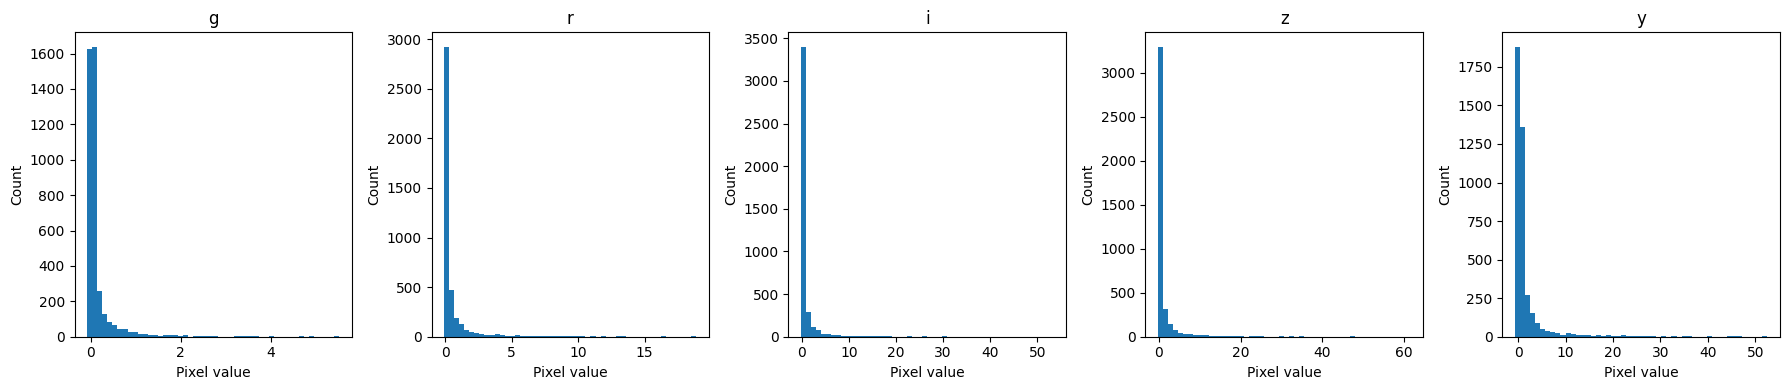

In [16]:
x=np.random.randint(1,images.shape[0])

bands = ["g", "r", "i", "z", "y"]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, ax in enumerate(axes):
    ax.hist(images[x, i].flatten(), bins=50)
    ax.set_title(bands[i])
    ax.set_xlabel("Pixel value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

Toma una imagen y espectro al azar y grafica

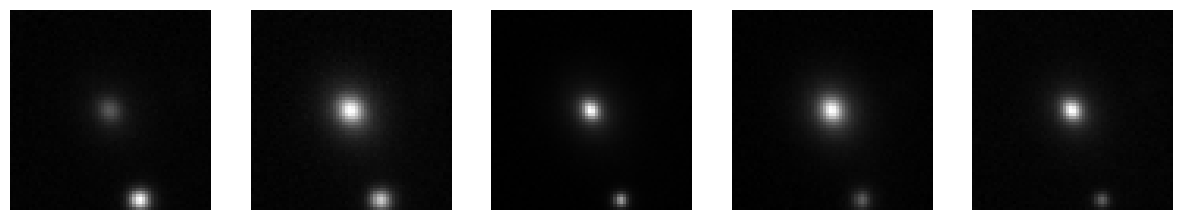

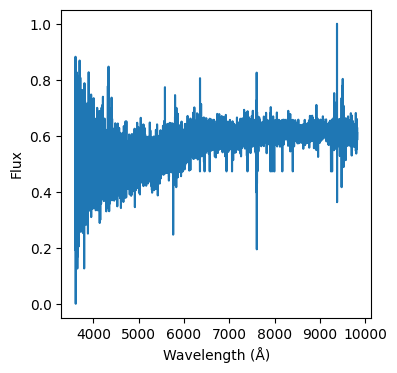

<Figure size 640x480 with 0 Axes>

59


In [ ]:
x=np.random.randint(1,images.shape[0])
image = images[x]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(image[i], cmap="gray")
    ax.axis("off")


flux_min = flux[x].min()
flux_max = flux[x].max()
flux_norm = (flux[x] - flux_min) / (flux_max - flux_min)

plt.figure(figsize=(4, 4))
plt.plot(wave[x], flux_norm)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.show()

plt.tight_layout()
plt.show()

print(desi_MORPHTYPE[x])




0


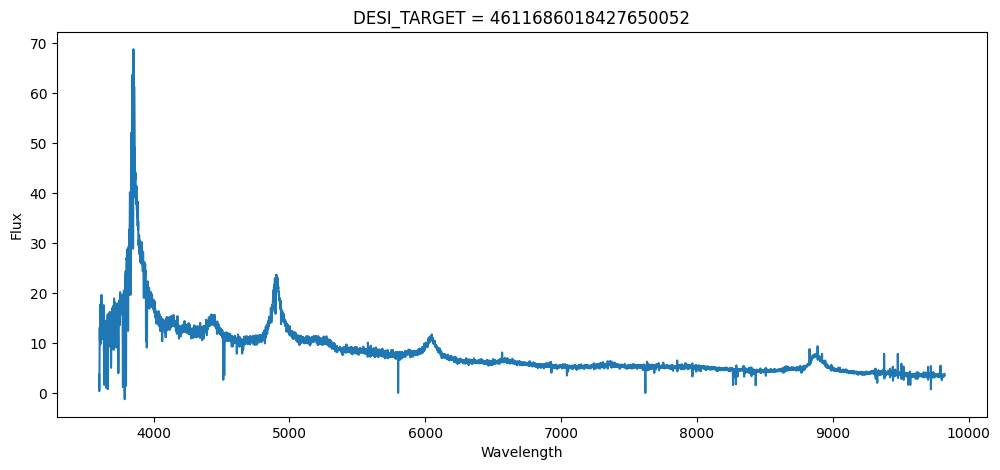

In [32]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

target_id=4611686018427650052
PATH='/Users/leopoldomorante/Desktop/vision_galaxiesML/DESI_HSC_64x64_v2.hdf5'
with h5py.File(PATH, "r") as f:

    desi_target = f["DESI_fibermap/DESI_TARGET"][:]


    # print(desi_target[0])
    # Find the index of the object
    indices = np.where(desi_target == target_id)[0]
    print(indices[0])

    if len(indices) == 0:
        print("DESI_TARGET not found")
    else:
        i = indices[0]

        wave = f["spectrum/wave"][i]
        flux = f["spectrum/flux"][i]

        plt.figure(figsize=(12, 5))
        plt.plot(wave, flux)
        plt.xlabel("Wavelength")
        plt.ylabel("Flux")
        plt.title(f"DESI_TARGET = {target_id}")
        plt.show()

Distribución de pares por valor de redshift (z)

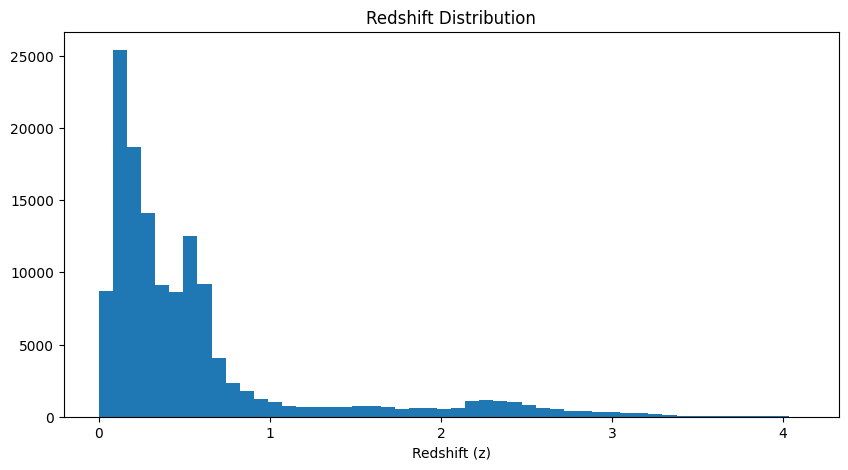

In [113]:
plt.figure(figsize=(10, 5))

plt.hist(redshifts, bins=50)

plt.xlabel("Redshift (z)")
# plt.ylabel("Number")
plt.title("Redshift Distribution")

plt.show()

In [104]:
with h5py.File(PATH, "r") as f:

    hsc = {
        name: f["HSC_metadata"][name][:]
        for name in f["HSC_metadata"]
    }

    desi = {
        name: f["DESI_fibermap"][name][:]
        for name in f["DESI_fibermap"]
    }

df_hsc = pd.DataFrame(hsc)
df_desi = pd.DataFrame(desi)

print(df_hsc.shape)
print(df_desi.shape)

(134533, 21)
(134533, 78)


In [105]:
df = pd.concat(
    [
        df_hsc.add_prefix("hsc_"),
        df_desi.add_prefix("desi_")
    ],
    axis=1
)

print(df.shape)
print(df.head())

(134533, 99)
                                           hsc_coord   hsc_dec  \
0  b'(-125539.703125, 163615.046875, -3881.992675... -1.078395   
1  b'(-126275.9140625, 163078.78125, -2207.639160... -0.613245   
2  b'(-126816.4296875, 162664.234375, -1763.64709... -0.489908   
3  b'(-126967.015625, 162553.09375, -1019.2875976... -0.283137   
4  b'(-126638.828125, 162811.578125, -411.4490661... -0.114291   

   hsc_g_cmodel_mag  hsc_g_cmodel_magsigma  hsc_i_cmodel_mag  \
0         19.314962               0.002069         19.069357   
1         22.783363               0.023962         19.711437   
2         20.732738               0.008319         18.307449   
3         19.830538               0.002307         19.711018   
4         22.329891               0.018621         19.730682   

   hsc_i_cmodel_magsigma  hsc_r_cmodel_mag  hsc_r_cmodel_magsigma      hsc_ra  \
0               0.001008         19.224197               0.001965  127.498559   
1               0.001926         20.857674 

In [28]:
df.columns

Index(['hsc_coord', 'hsc_dec', 'hsc_g_cmodel_mag', 'hsc_g_cmodel_magsigma',
       'hsc_i_cmodel_mag', 'hsc_i_cmodel_magsigma', 'hsc_r_cmodel_mag',
       'hsc_r_cmodel_magsigma', 'hsc_ra', 'hsc_skymap_id', 'hsc_specz_dec',
       'hsc_specz_flag_homogeneous', 'hsc_specz_mag_i', 'hsc_specz_name',
       'hsc_specz_ra', 'hsc_specz_redshift', 'hsc_specz_redshift_err',
       'hsc_y_cmodel_mag', 'hsc_y_cmodel_magsigma', 'hsc_z_cmodel_mag',
       'hsc_z_cmodel_magsigma', 'desi_BGS_TARGET', 'desi_BRICKID',
       'desi_BRICKNAME', 'desi_BRICK_OBJID', 'desi_COADD_EXPTIME',
       'desi_COADD_FIBERSTATUS', 'desi_COADD_NUMEXP', 'desi_COADD_NUMNIGHT',
       'desi_COADD_NUMTILE', 'desi_DESI_TARGET', 'desi_DESI_redshift',
       'desi_DESI_redshift_err', 'desi_EBV', 'desi_FA_TARGET', 'desi_FA_TYPE',
       'desi_FIBERFLUX_G', 'desi_FIBERFLUX_R', 'desi_FIBERFLUX_Z',
       'desi_FIBERTOTFLUX_G', 'desi_FIBERTOTFLUX_R', 'desi_FIBERTOTFLUX_Z',
       'desi_FLUX_G', 'desi_FLUX_IVAR_G', 'desi_FLUX_IV

In [ ]:
df["desi_MORPHTYPE"].unique().sort()
df["desi_MORPHTYPE"]


0         b'PSF'
1         b'DEV'
2         b'DEV'
3         b'PSF'
4         b'SER'
           ...  
134528    b'SER'
134529    b'DEV'
134530    b'SER'
134531    b'PSF'
134532    b'PSF'
Name: desi_MORPHTYPE, Length: 134533, dtype: object

In [ ]:
# pip install "setuptools<81"

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="GalaxiesML Dataset Profile",
    explorative=True
)

profile.to_file("galaxies_profile.html")